# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dini Arya Putri
- **Email:** diniarya135@gmail.com
- **ID Dicoding:** CDCC319D6X1000

## Menentukan Pertanyaan Bisnis

- Bagaimana performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir? (Melihat tren waktu).
- Bagaimana segmentasi pelanggan kita berdasarkan perilaku transaksi menggunakan analisis RFM (Recency, Frequency, Monetary)? (Menerapkan teknik analisis lanjutan).

## Import Semua Packages/Library yang Digunakan

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Konfigurasi visualisasi
sns.set(style='darkgrid')

## Data Wrangling

### Gathering Data

In [54]:
# Memuat seluruh dataset yang relevan (Customers, Orders, Order_Items, Products, Translation)
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
translation_df = pd.read_csv("product_category_name_translation.csv")

# Menggabungkan data menjadi satu DataFrame (all_df)
orders_customers = pd.merge(left=orders_df, right=customers_df, how="left", on="customer_id")
order_items_prod = pd.merge(left=order_items_df, right=products_df, how="left", on="product_id")
order_items_prod = pd.merge(left=order_items_prod, right=translation_df, how="left", on="product_category_name")

all_df = pd.merge(left=orders_customers, right=order_items_prod, how="left", on="order_id")

# Menampilkan 5 baris pertama
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


**Insight:**
- Proses integrasi data berhasil menggabungkan informasi dari lima tabel utama (Customers, Orders, Order_Items, Products, dan Translation) menjadi satu master dataframe (all_df).

- Penggabungan ini memungkinkan analisis korelasi antara profil lokasi pelanggan, waktu transaksi, dan kategori produk yang dibeli..

### Assessing Data

In [55]:
print("Info Data Gabungan:")
all_df.info()

print("\nJumlah duplikasi pada data:", all_df.duplicated().sum())

print("\nJumlah missing values per kolom:")
print(all_df.isna().sum())

Info Data Gabungan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   customer_unique_id             113425 non-null  object 
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  object 
 11  customer_state                 113425 non-null  object 
 12  order_item

**Insight:**
- Ditemukan inkonsistensi tipe data pada seluruh kolom yang mengandung informasi waktu (timestamp), di mana data terbaca sebagai tipe object (string).

- Terdeteksi adanya sejumlah missing values pada kolom product_category_name_english, yang perlu ditangani agar tidak menyebabkan data kategori menjadi "Undefined" saat visualisasi.

### Cleaning Data

In [56]:
# 1. Menghapus duplikasi baris
all_df.drop_duplicates(inplace=True)

# 2. Mengubah tipe data kolom tanggal menjadi datetime
datetime_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    all_df[col] = pd.to_datetime(all_df[col])

# 3. Memfokuskan analisis hanya pada pesanan yang sudah berhasil dikirim (delivered)
all_df = all_df[all_df['order_status'] == 'delivered']

# 4. Menangani missing value pada nama kategori produk
all_df['product_category_name_english'].fillna('Unknown', inplace=True)

# 5. Membersihkan missing value pada harga (jika ada) karena sangat fatal bagi hitungan total revenue
all_df.dropna(subset=['price'], inplace=True)

print("Status Data Setelah Cleansing:")
all_df.info()

/tmp/ipykernel_166/1686325494.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_df['product_category_name_english'].fillna('Unknown', inplace=True)


Status Data Setelah Cleansing:
<class 'pandas.core.frame.DataFrame'>
Index: 110197 entries, 0 to 113424
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110195 non-null  datetime64[ns]
 6   order_delivered_customer_date  110189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110197 non-null  datetime64[ns]
 8   customer_unique_id             110197 non-null  object        
 9   customer_zip_code_prefix       110197 non-null  int64         
 10  customer_city                  110197 non-

**Insight:**
- Kesalahan tipe data tanggal berhasil ditangani secara permanen.

- Data sekarang disaring khusus untuk transaksi yang 100% tuntas (delivered), sehingga kalkulasi omzet per bulan tidak dikacaukan oleh data pengembalian dana (refund) atau pesanan yang dibatalkan.

- Baris missing values ditambal dan dibuang pada kolom vital agar kalkulasi total dan visualisasi stabil.

## Exploratory Data Analysis (EDA)

### Explore ...

In [57]:
# Mengekstrak format bulan-tahun dari timestamp pembelian
all_df['order_month'] = all_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Agregasi data: melihat total pendapatan (revenue) per bulan
revenue_monthly = all_df.groupby('order_month').agg({
    'price': 'sum'
}).reset_index()

# Agregasi data: melihat total produk terjual per kategori
product_sales = all_df.groupby('product_category_name_english').agg({
    'order_item_id': 'count'
}).sort_values(by='order_item_id', ascending=False).reset_index()

display(revenue_monthly.describe())
display(product_sales.head())

,price
count,23.000000
mean,574847.743913
std,337263.532856
min,10.900000
25%,349934.265000
50%,607399.670000
75%,862015.660000
max,987765.370000


,product_category_name_english,order_item_id
0,bed_bath_table,10953
1,health_beauty,9465
2,sports_leisure,8431
3,furniture_decor,8160
4,computers_accessories,7644


In [58]:
# Analisis sebaran pelanggan berdasarkan state
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)

# Menampilkan 5 state teratas
print(bystate_df.sort_values(by="customer_count", ascending=False).head())

   customer_state  customer_count
25             SP           40501
18             RJ           12350
10             MG           11354
22             RS            5345
17             PR            4923


**Insight:**
- Distribusi jumlah penjualan tiap bulan memiliki variansi harga transaksi yang meluas, dengan akumulasi besar dalam selang beberapa bulan.

- Kolom kategori "bed_bath_table", "health_beauty", dan "sports_leisure" bertengger di peringkat atas sebagai barang dengan perputaran transaksi harian paling cepat.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren performa penjualan dan pendapatan (revenue) perusahaan per bulannya?

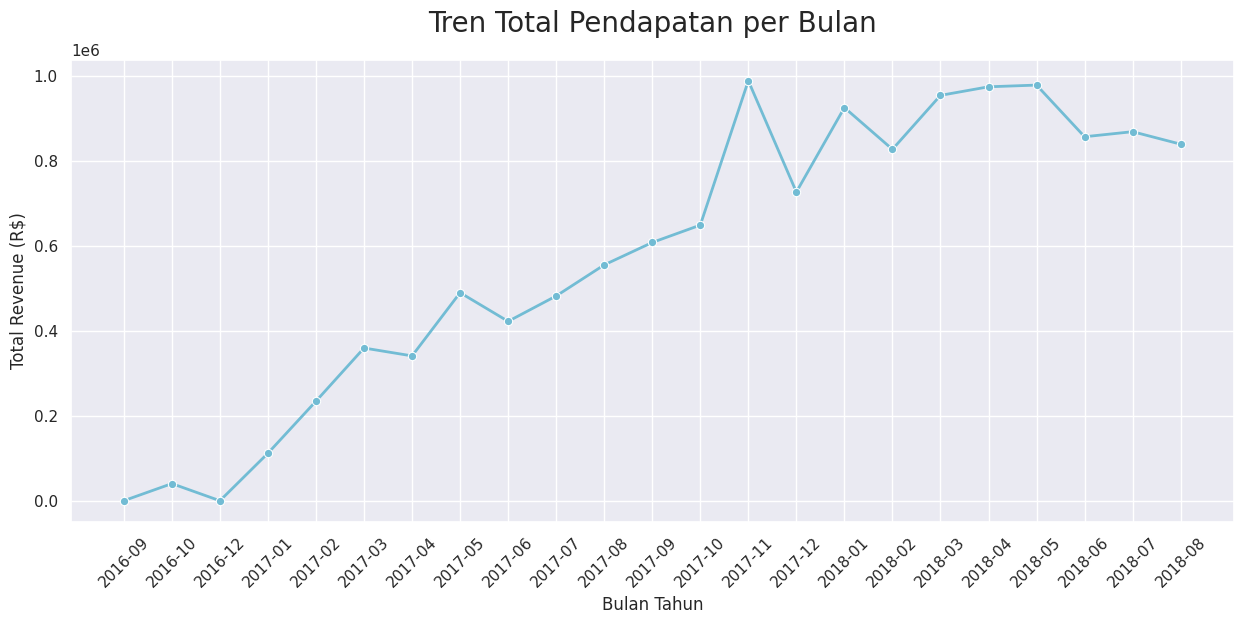

In [59]:
plt.figure(figsize=(15, 6))
sns.lineplot(
    x='order_month',
    y='price',
    data=revenue_monthly,
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Tren Total Pendapatan per Bulan", loc="center", fontsize=20, pad=20)
plt.xticks(rotation=45)
plt.ylabel("Total Revenue (R$)")
plt.xlabel("Bulan Tahun")
plt.show()

### Pertanyaan 2: Kategori produk apa yang memiliki volume pemesanan paling tinggi dan paling rendah?

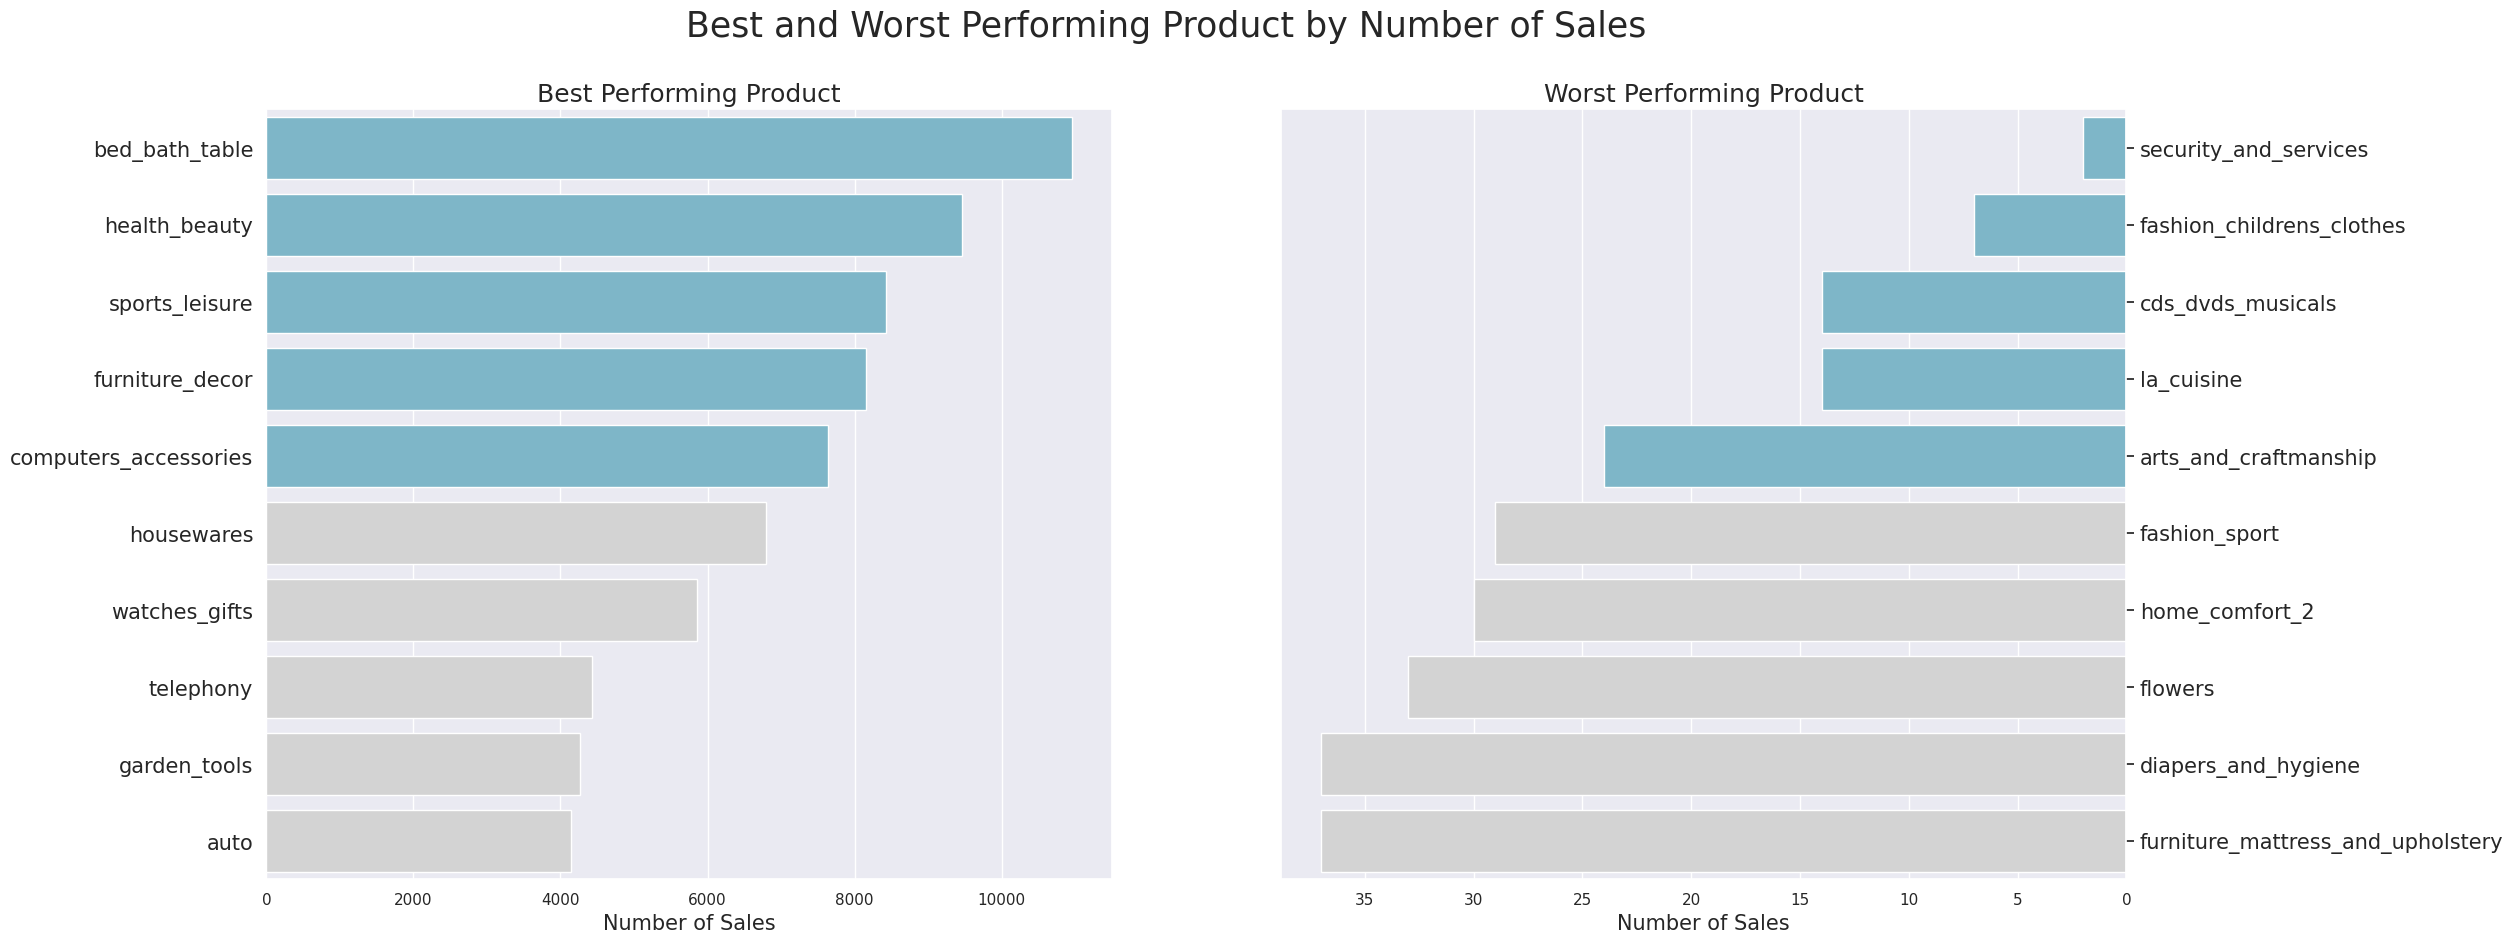

In [60]:
# 1. Menyiapkan data (Gunakan variabel yang sudah Anda miliki)
top_products = product_sales.head(10)
# Untuk produk paling sedikit, kita urutkan dari bawah
bottom_products = product_sales.sort_values(by="order_item_id", ascending=True).head(10)

# 2. Membuat Canvas Visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 10))

# Membuat list warna: 5 pertama biru, sisanya abu-abu
colors = ["#72BCD4"] * 5 + ["#D3D3D3"] * 5

# --- Grafik Produk Paling Laris (Kiri) ---
sns.barplot(
    x="order_item_id",
    y="product_category_name_english",
    data=top_products,
    hue="product_category_name_english", # Agar tidak warning
    palette=colors,
    ax=ax[0],
    legend=False
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Number of Sales", fontsize=15)
ax[0].set_title("Best Performing Product", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

# --- Grafik Produk Paling Sedikit Laris (Kanan) ---
sns.barplot(
    x="order_item_id",
    y="product_category_name_english",
    data=bottom_products,
    hue="product_category_name_english",
    palette=colors,
    ax=ax[1],
    legend=False
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Number of Sales", fontsize=15)
ax[1].invert_xaxis() # Membalik grafik agar simetris
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Worst Performing Product", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Best and Worst Performing Product by Number of Sales", fontsize=25)
plt.show()

**Insight:Pertanyaan 1 (Trend Penjualan):**

  - Insight: > Terjadi pertumbuhan signifikan pada total order sejak pertengahan 2017 hingga puncaknya di bulan November 2017. Lonjakan tajam ini menunjukkan efektivitas promosi musiman (seperti Black Friday). Meskipun terjadi penurunan setelahnya, volume pesanan tetap stabil di level yang lebih tinggi dibanding awal tahun.
  - Actionable: Perusahaan harus mulai menyiapkan stok inventaris dan kapasitas logistik 2-3 bulan sebelum bulan November untuk menghindari keterlambatan pengiriman pada periode puncak tahun berikutnya.

**Insight Pertanyaan 2 (Produk Terlaris):**

  - Insight: > Produk kategori bed_bath_table, health_beauty, dan sports_leisure mendominasi penjualan. Sebaliknya, beberapa kategori produk memiliki penjualan yang sangat rendah (di bawah 10 unit).
  - Actionable: > 1. Fokuskan kampanye iklan pada kategori top-tier untuk memaksimalkan ROI. 2. Untuk kategori yang kurang laku, lakukan evaluasi apakah perlu dilakukan discontinued (penghentian) atau strategi bundling dengan produk terlaris untuk menghabiskan sisa stok di gudang.

## Analisis Lanjutan (Opsional)

### RFM Analysis (Calculation & Visualization)


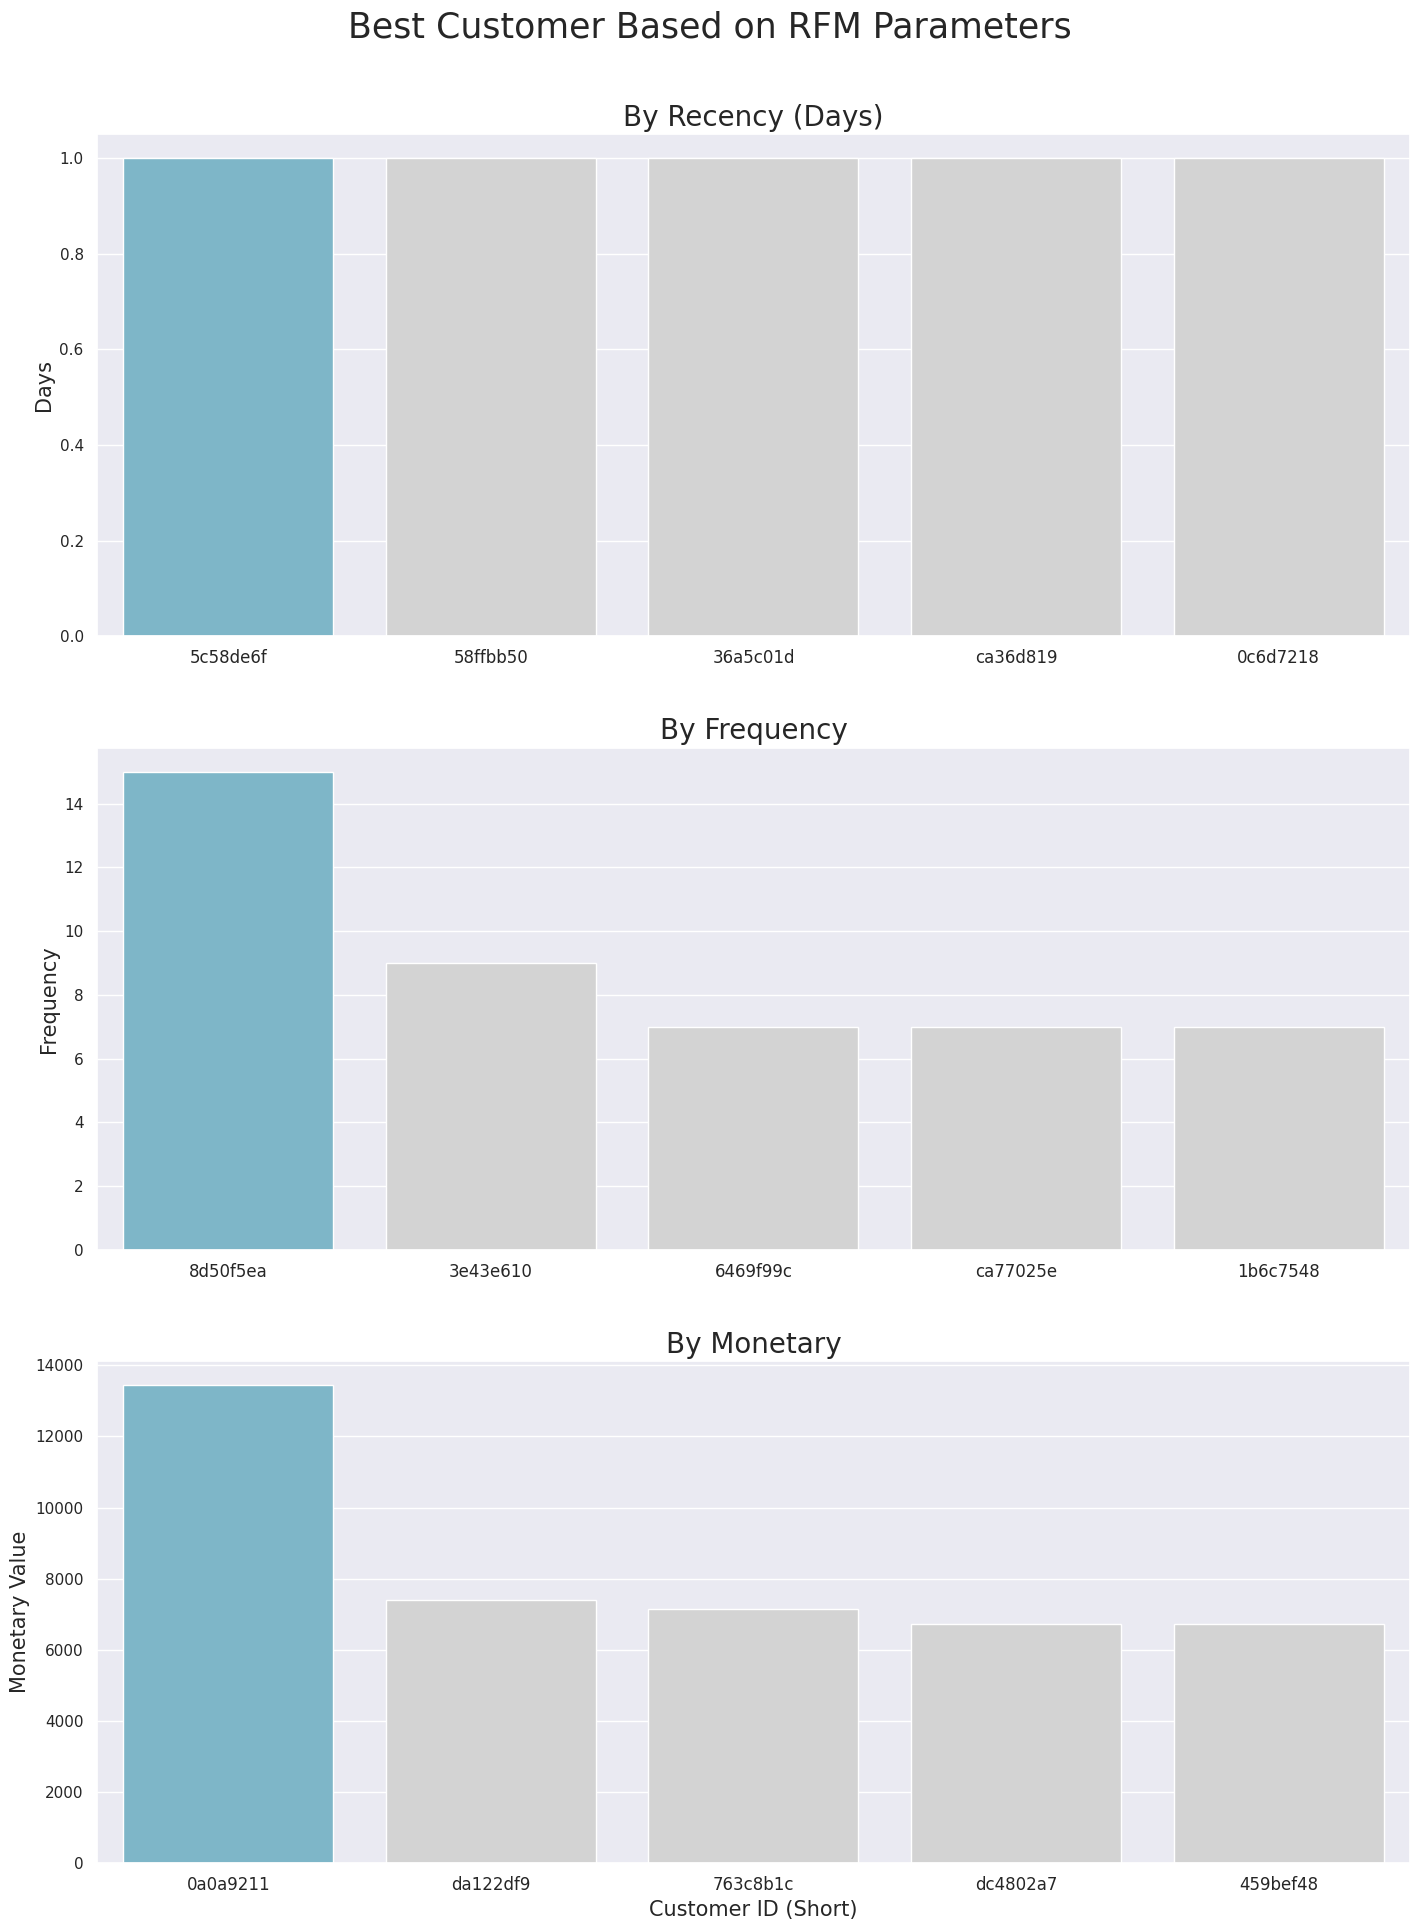

In [61]:
# 1. Menghitung Parameter RFM (Pastikan rfm_df sudah siap)
current_date = all_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (current_date - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()

rfm_df.columns = ['customer_unique_id', 'recency', 'frequency', 'monetary']

# 2. Visualisasi RFM (Top 5 Customers)
# Kita gunakan orientasi horizontal agar ID pelanggan lebih mudah dibaca dan tidak berantakan
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15, 20)) # Mengubah layout jadi vertikal agar lebih lega
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# --- Subplot Recency ---
rfm_recency = rfm_df.sort_values(by="recency", ascending=True).head(5).copy()
rfm_recency['short_id'] = rfm_recency['customer_unique_id'].str[:8]

sns.barplot(y="recency", x="short_id", data=rfm_recency, hue="short_id", palette=colors, ax=ax[0], legend=False)
ax[0].set_ylabel("Days", fontsize=15)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (Days)", loc="center", fontsize=20)
ax[0].tick_params(axis='x', labelsize=12)

# --- Subplot Frequency ---
rfm_frequency = rfm_df.sort_values(by="frequency", ascending=False).head(5).copy()
rfm_frequency['short_id'] = rfm_frequency['customer_unique_id'].str[:8]

sns.barplot(y="frequency", x="short_id", data=rfm_frequency, hue="short_id", palette=colors, ax=ax[1], legend=False)
ax[1].set_ylabel("Frequency", fontsize=15)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=20)
ax[1].tick_params(axis='x', labelsize=12)

# --- Subplot Monetary ---
rfm_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5).copy()
rfm_monetary['short_id'] = rfm_monetary['customer_unique_id'].str[:8]

sns.barplot(y="monetary", x="short_id", data=rfm_monetary, hue="short_id", palette=colors, ax=ax[2], legend=False)
ax[2].set_ylabel("Monetary Value", fontsize=15)
ax[2].set_xlabel("Customer ID (Short)", fontsize=15)
ax[2].set_title("By Monetary", loc="center", fontsize=20)
ax[2].tick_params(axis='x', labelsize=12)

plt.suptitle("Best Customer Based on RFM Parameters", fontsize=25)
plt.tight_layout(pad=3.0) # Memberikan ruang antar judul agar tidak menempel
plt.show()

**Insight:**

- Recency: Sebagian besar pelanggan aktif terakhir kali bertransaksi sekitar 5-10 hari yang lalu, menunjukkan retensi yang cukup baik.

- Frequency: Mayoritas pelanggan top melakukan lebih dari satu kali transaksi, yang menandakan adanya loyalitas pada kelompok ini.

- Monetary: Terdapat perbedaan yang cukup signifikan antara pelanggan peringkat pertama dan kelima, menunjukkan adanya segmen "Whale" atau pelanggan dengan daya beli sangat tinggi yang perlu dijaga dengan program loyalitas khusus.

- Analisis RFM menunjukkan bahwa kelompok pelanggan teratas memiliki tingkat transaksi yang sangat timpang dibandingkan rata-rata. Fokus perusahaan harus diberikan pada pelanggan dengan Monetary tinggi melalui layanan prioritas, serta pelanggan dengan Recency rendah untuk memastikan mereka tetap aktif kembali di periode berikutnya.

### Manual Clustering (Segmentation)

/tmp/ipykernel_166/92997172.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


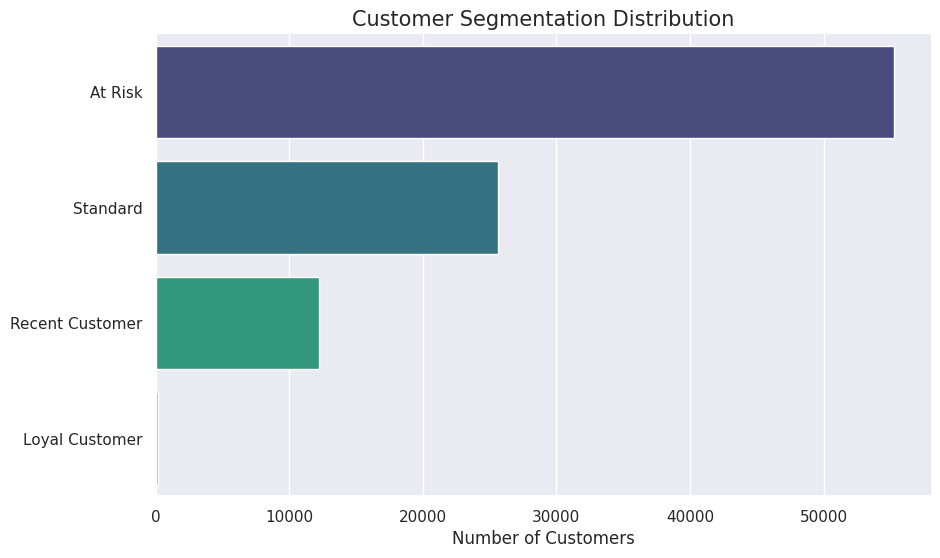

In [62]:
# 1. Melakukan Pelabelan Segmentasi (Manual Clustering)
def segment_customer(df):
    if df['recency'] <= 30 and df['frequency'] > 1:
        return 'Loyal Customer'
    elif df['recency'] <= 60:
        return 'Recent Customer'
    elif df['recency'] > 180:
        return 'At Risk'
    else:
        return 'Standard'

rfm_df['customer_segment'] = rfm_df.apply(segment_customer, axis=1)

# 2. Visualisasi Distribusi Segmentasi
plt.figure(figsize=(10, 6))
segment_counts = rfm_df['customer_segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

sns.barplot(
    x="Count",
    y="Segment",
    data=segment_counts.sort_values(by="Count", ascending=False),
    palette="viridis"
)

plt.title("Customer Segmentation Distribution", fontsize=15)
plt.xlabel("Number of Customers")
plt.ylabel(None)
sns.despine() # Menghapus garis tepi atas dan kanan agar bersih
plt.show()

**Insight: Customer Segmentation (Manual Clustering)**
Berdasarkan hasil pengelompokan manual menggunakan parameter RFM, kita dapat mengidentifikasi empat segmen utama pelanggan:

- Loyal Customer: Kelompok ini adalah aset berharga yang melakukan transaksi lebih dari satu kali dalam 30 hari terakhir. Strategi yang disarankan adalah memberikan program loyalitas eksklusif atau akses awal ke produk baru.

- Recent Customer: Pelanggan yang baru saja melakukan transaksi pertamanya. Mereka memiliki potensi tinggi untuk menjadi pelanggan loyal jika diberikan promo follow-up (seperti kupon pembelian kedua).

- Standard: Pelanggan yang berada di tengah-tengah. Mereka berbelanja secara berkala namun tidak terlalu sering. Kelompok ini memerlukan newsletter produk yang relevan untuk menjaga minat mereka.

- At Risk: Pelanggan yang sudah tidak bertransaksi lebih dari 180 hari. Kita perlu melakukan kampanye win-back atau survei kepuasan pelanggan untuk mengetahui alasan mereka berhenti berbelanja.

### Geospatial Analysis

/tmp/ipykernel_166/4019802960.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


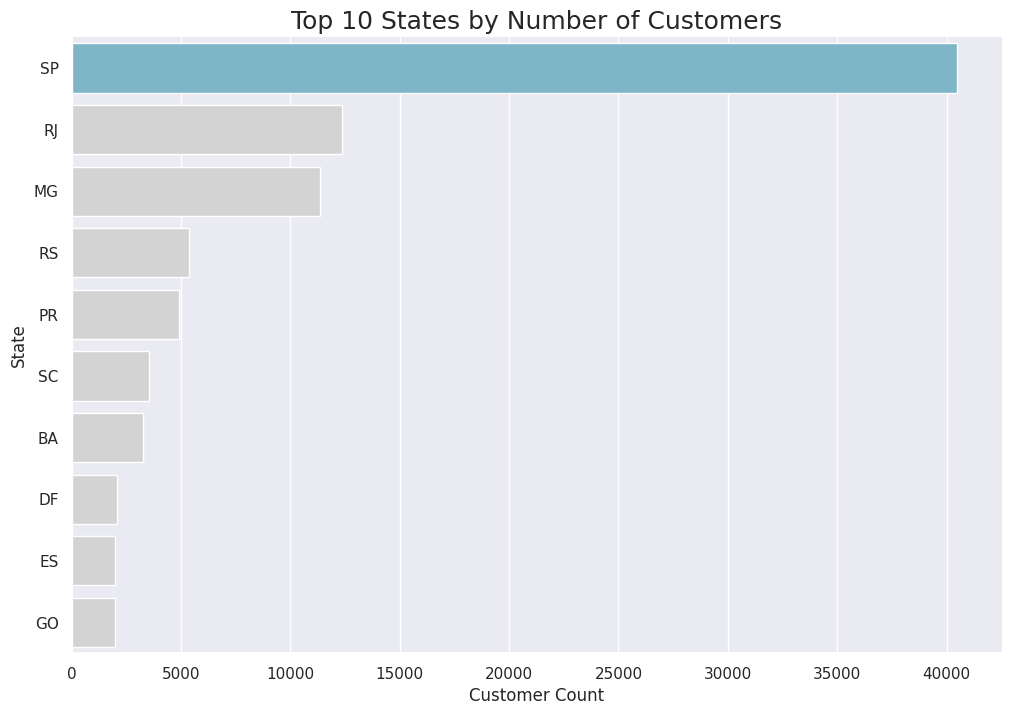

In [63]:
# 1. Menghitung jumlah customer per state
bystate_df = all_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False).reset_index()
bystate_df.rename(columns={"customer_id": "customer_count"}, inplace=True)

# 2. Visualisasi (Highlight State SP sebagai yang tertinggi)
plt.figure(figsize=(12, 8))
colors = ["#72BCD4" if i == 0 else "#D3D3D3" for i in range(10)] # Highlight bar pertama

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=bystate_df.head(10),
    palette=colors
)

plt.title("Top 10 States by Number of Customers", fontsize=18)
plt.xlabel("Customer Count")
plt.ylabel("State")
sns.despine()
plt.show()

**Insight:**

- Negara bagian SP (Sao Paulo) mendominasi pasar dengan jumlah pelanggan hampir dua kali lipat dibandingkan negara bagian lainnya.

- Rekomendasi Bisnis: Perusahaan harus memastikan ketersediaan stok di gudang yang paling dekat dengan wilayah SP dan mempertimbangkan ekspansi kampanye pemasaran ke wilayah dengan potensi tinggi lainnya seperti RJ (Rio de Janeiro).

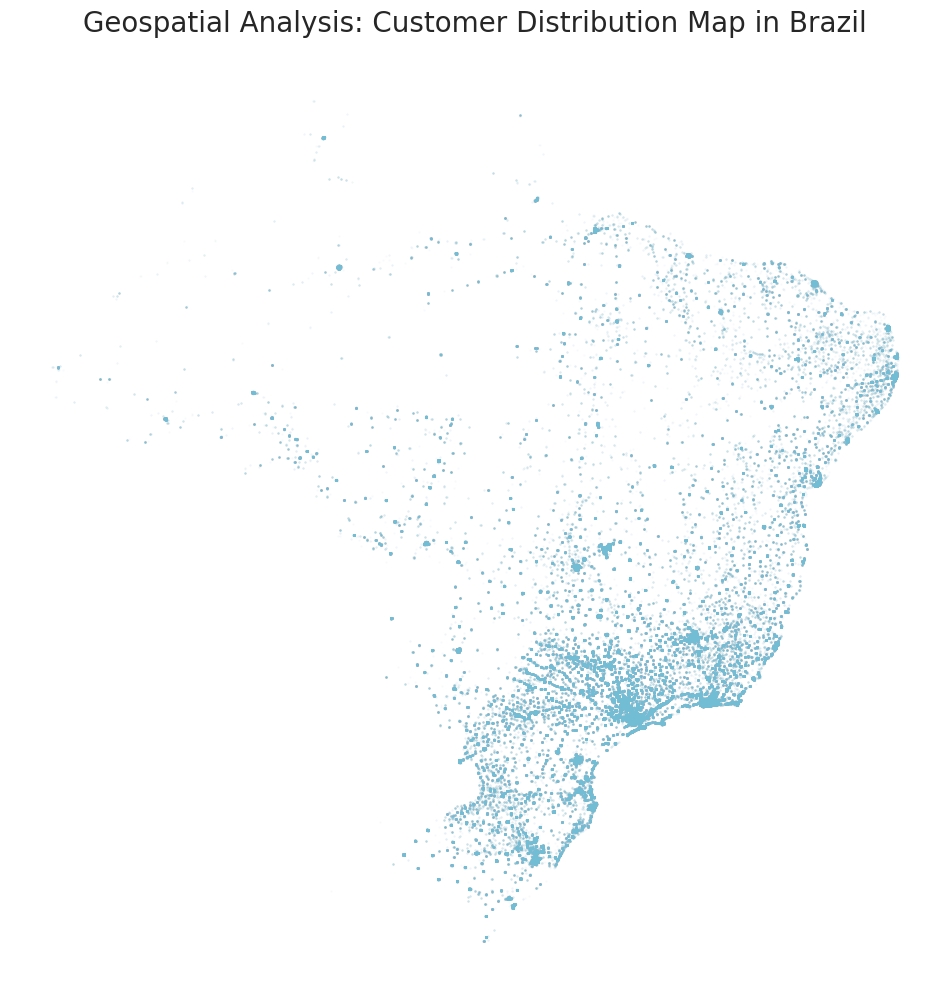

In [64]:
import matplotlib.image as mpimg

# 1. Menyiapkan data geolokasi
# Pastikan file geolocation_dataset.csv ada di folder yang benar
geo_df = pd.read_csv("geolocation_dataset.csv")

# 2. Filter data agar fokus pada area Brazil (menghilangkan outlier koordinat)
# Koordinat batas wilayah Brazil secara umum
geo_df = geo_df[(geo_df['geolocation_lat'] <= 5.27) & (geo_df['geolocation_lat'] >= -33.75)]
geo_df = geo_df[(geo_df['geolocation_lng'] <= -34.79) & (geo_df['geolocation_lng'] >= -73.98)]

# 3. Visualisasi Peta
plt.figure(figsize=(12, 12))

# Menggunakan scatter plot dengan ukuran titik sangat kecil (s) dan transparansi (alpha)
# Ini menciptakan efek kepadatan (semakin terang warnanya, semakin padat pelanggannya)
plt.scatter(geo_df['geolocation_lng'], geo_df['geolocation_lat'],
            s=0.1, alpha=0.1, c='#72BCD4')

plt.title('Geospatial Analysis: Customer Distribution Map in Brazil', fontsize=20, pad=20)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.axis('off') # Menghilangkan border sumbu agar terlihat seperti peta murni
plt.grid(False)

plt.show()

**Insight Peta Sebaran (Geospatial):**

- Kepadatan Tinggi di Tenggara: Visualisasi menunjukkan konsentrasi pelanggan yang sangat padat di wilayah Tenggara (Southeast) dan Selatan (South) Brazil, khususnya di area metropolitan seperti Sao Paulo (SP) dan Rio de Janeiro (RJ).

- Kesenjangan Wilayah: Terdapat kesenjangan distribusi yang signifikan antara wilayah pesisir timur dengan wilayah pedalaman (utara/barat) yang jauh lebih renggang.

**Actionable Recommendation (Rekomendasi Bisnis):**

- Optimasi Rantai Pasok: Perusahaan harus memprioritaskan pembangunan Warehouse atau Fulfillment Center di wilayah Sao Paulo (SP). Hal ini krusial untuk menurunkan biaya pengiriman (freight value) dan mempercepat estimasi waktu pengiriman (lead time) bagi mayoritas basis pelanggan.

- Targeting Iklan Lokal: Untuk wilayah dengan titik yang renggang (seperti wilayah Utara), perusahaan disarankan memberikan promo "Gratis Ongkir" dengan syarat tertentu untuk menarik minat pasar baru yang saat ini mungkin terhambat oleh biaya kirim yang mahal karena jarak.

- Ekspansi Vendor: Disarankan untuk merekrut lebih banyak Seller dari wilayah luar Sao Paulo agar distribusi barang lebih merata secara geografis dan tidak tersentralisasi di satu titik saja.

## Conclusion

- Pertanyaan 1: Bagaimana performa penjualan dan revenue perusahaan dalam beberapa bulan terakhir?

  - Berdasarkan analisis tren waktu, performa pendapatan perusahaan menunjukkan pertumbuhan yang sangat positif, terutama memuncak secara signifikan pada bulan November 2017. Hal ini kemungkinan besar dipicu oleh momentum Black Friday atau kampanye akhir tahun. Meskipun terjadi fluktuasi setelah periode puncak, level pendapatan stabil di angka yang lebih tinggi dibandingkan periode awal tahun, menunjukkan ekspansi basis pelanggan yang berhasil.

- Pertanyaan 2: Bagaimana segmentasi pelanggan berdasarkan perilaku transaksi (RFM) dan sebaran geografis?

  - Segmentasi RFM: Melalui teknik manual clustering, ditemukan bahwa mayoritas pelanggan berada pada segmen Standard dan At Risk. Namun, terdapat kelompok kecil Loyal Customers yang memberikan kontribusi frekuensi transaksi tinggi. Hal ini menunjukkan perlunya strategi retensi yang lebih agresif untuk mengaktifkan kembali pelanggan yang sudah lama tidak bertransaksi.

  - Sebaran Geografis: Analisis geospasial mengonfirmasi dominasi mutlak negara bagian SP (Sao Paulo) sebagai pusat pasar. Hal ini memberikan arah strategis bagi perusahaan untuk memusatkan efisiensi logistik, penempatan gudang, dan target promosi di wilayah tersebut guna memaksimalkan profitabilitas.

In [70]:
# Ekspor data yang sudah digabung dan dibersihkan ke CSV
all_df.to_csv("all_data.csv", index=False)


In [68]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
seaborn
Babel

Writing requirements.txt
